In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import scipy
import codecs
import re
import nltk
import nltk.stem.porter
from sklearn.model_selection import train_test_split
import numpy as np
import codecs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import torch
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim



### **PARTE 1 SVM**

In [ ]:
#FUNCION AUXILIAR PARA DIBUJAR LA FRONTERA
def plot_decision_boundary(X, y, svm):
  x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
  x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
  x1, x2 = np.meshgrid(x1, x2)
  yp = svm.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)
  plt.figure()
  plt.contour(x1, x2, yp)
  plt.scatter(X[:, 0], X[:, 1], c=y)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
data = scipy.io.loadmat('ex6data1.mat', squeeze_me=True)
y = data['y']
X = data['X']


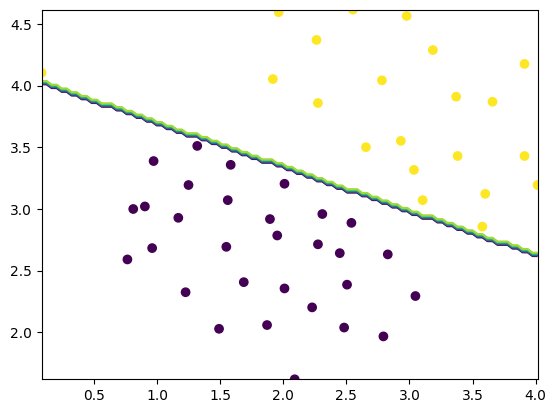

In [ ]:
#KERNEL LINEAL
#ejecutamos sobre un conjunto de datos de entrenamiento X
#con c = 1 y c =100 para ver la diferencia
svm = SVC(kernel='linear', C=100)
svm.fit(X,y)
plot_decision_boundary(X, y, svm)


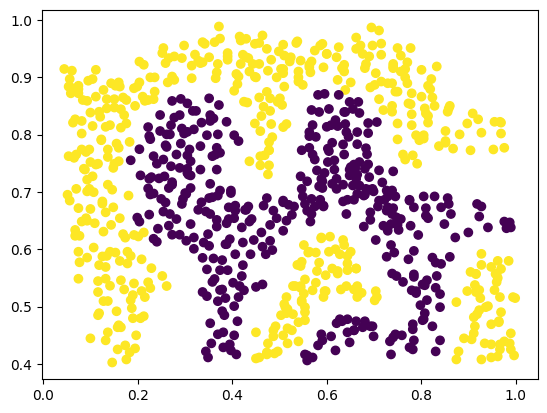

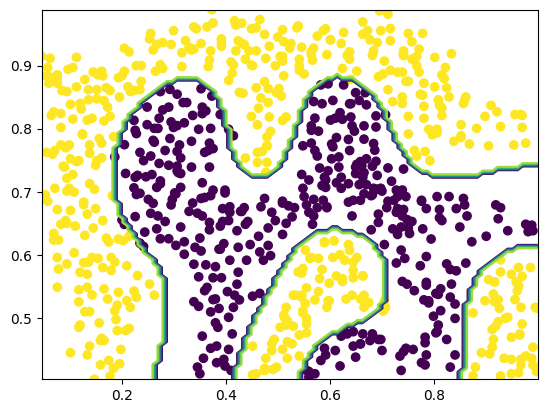

In [ ]:
#KERNEL GAUSSIANO


#cargamos datos
data = scipy.io.loadmat('ex6data2.mat', squeeze_me=True)
y = data['y']
X = data['X']

##dibujamos los datos
plt.scatter(X[:, 0], X[:, 1], c=y)


#creamos svc con kernel gausiano y dibujamos
C= 1
sigma = 0.1
svmGauss = SVC(kernel='rbf', C=C,  gamma=1 / (2 * sigma**2))
svmGauss.fit(X,y)
plot_decision_boundary(X, y, svmGauss)



In [ ]:
##ELECCIÓN DE C Y SIGMA CON DATOS DE EVALUACION

#cargamos datos
data = scipy.io.loadmat('ex6data3.mat', squeeze_me=True)
y = data['y']
X = data['X']
Xval = data['Xval']
yval = data['yval']

valores = [0.01,0.03,0.1,0.3,1,3,10,30]

for valC in valores:
  for valSig in valores:
    svmGaussIdeal = SVC(kernel='rbf', C=valC,  gamma=1 / (2 * valSig**2))
    svmGaussIdeal.fit(X,y)
    ##evaluamos sobre los datos eval
    ##usando la funcion de score de svm
    #Return the mean accuracy on the given test data and labels
    score = svmGaussIdeal.score(Xval, yval)
    print("Score:", score, "C:", valC, "Sigma:", valSig)



Score: 0.435 C: 0.01 Sigma: 0.01
Score: 0.435 C: 0.01 Sigma: 0.03
Score: 0.435 C: 0.01 Sigma: 0.1
Score: 0.435 C: 0.01 Sigma: 0.3
Score: 0.435 C: 0.01 Sigma: 1
Score: 0.435 C: 0.01 Sigma: 3
Score: 0.435 C: 0.01 Sigma: 10
Score: 0.435 C: 0.01 Sigma: 30
Score: 0.435 C: 0.03 Sigma: 0.01
Score: 0.435 C: 0.03 Sigma: 0.03
Score: 0.45 C: 0.03 Sigma: 0.1
Score: 0.86 C: 0.03 Sigma: 0.3
Score: 0.62 C: 0.03 Sigma: 1
Score: 0.435 C: 0.03 Sigma: 3
Score: 0.435 C: 0.03 Sigma: 10
Score: 0.435 C: 0.03 Sigma: 30
Score: 0.435 C: 0.1 Sigma: 0.01
Score: 0.435 C: 0.1 Sigma: 0.03
Score: 0.945 C: 0.1 Sigma: 0.1
Score: 0.91 C: 0.1 Sigma: 0.3
Score: 0.825 C: 0.1 Sigma: 1
Score: 0.435 C: 0.1 Sigma: 3
Score: 0.435 C: 0.1 Sigma: 10
Score: 0.435 C: 0.1 Sigma: 30
Score: 0.435 C: 0.3 Sigma: 0.01
Score: 0.755 C: 0.3 Sigma: 0.03
Score: 0.96 C: 0.3 Sigma: 0.1
Score: 0.925 C: 0.3 Sigma: 0.3
Score: 0.89 C: 0.3 Sigma: 1
Score: 0.74 C: 0.3 Sigma: 3
Score: 0.435 C: 0.3 Sigma: 10
Score: 0.435 C: 0.3 Sigma: 30
Score: 0.605 C:

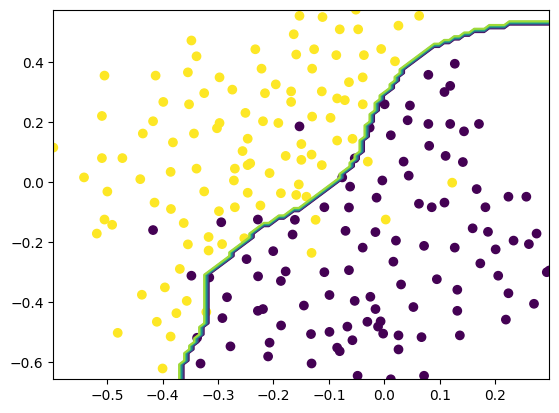

In [ ]:
#Conseguimos la mayor precision para los valores C =1 y sigma = 0.1, precision de 0.965
svmGaussIdealFit = SVC(kernel='rbf', C=1,  gamma=1 / (2 * 0.1**2))
svmGaussIdealFit.fit(X,y)
plot_decision_boundary(X, y, svmGaussIdealFit)

## **PARTE 2: DETECCIÓN DE SPAM**

### **PROCESAMIENTO DE DATOS**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vocab.txt to vocab.txt


In [ ]:
import zipfile
import io

uploaded_file_name = 'data.zip'  # Reemplaza 'nombre_del_archivo.zip' con el nombre real del archivo que subiste
with zipfile.ZipFile(io.BytesIO(uploaded[uploaded_file_name]), 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:

def preProcess(email):

    hdrstart = email.find("\n\n")
    if hdrstart != -1:
        email = email[hdrstart:]

    email = email.lower()
    # Strip html tags. replace with a space
    email = re.sub('<[^<>]+>', ' ', email)
    # Any numbers get replaced with the string 'number'
    email = re.sub('[0-9]+', 'number', email)
    # Anything starting with http or https:// replaced with 'httpaddr'
    email = re.sub('(http|https)://[^\s]*', 'httpaddr', email)
    # Strings with "@" in the middle are considered emails --> 'emailaddr'
    email = re.sub('[^\s]+@[^\s]+', 'emailaddr', email)
    # The '$' sign gets replaced with 'dollar'
    email = re.sub('[$]+', 'dollar', email)
    return email


def email2TokenList(raw_email):
    """
    Function that takes in a raw email, preprocesses it, tokenizes it,
    stems each word, and returns a list of tokens in the e-mail
    """

    stemmer = nltk.stem.porter.PorterStemmer()
    email = preProcess(raw_email)

    # Split the e-mail into individual words (tokens)
    tokens = re.split('[ \@\$\/\#\.\-\:\&\*\+\=\[\]\?\!\(\)\{\}\,\'\"\>\_\<\;\%]',
                      email)

    # Loop over each token and use a stemmer to shorten it
    tokenlist = []
    for token in tokens:

        token = re.sub('[^a-zA-Z0-9]', '', token)
        stemmed = stemmer.stem(token)
        # Throw out empty tokens
        if not len(token):
            continue
        # Store a list of all unique stemmed words
        tokenlist.append(stemmed)

    return tokenlist


def getVocabDict(reverse=False):
    """
    Function to read in the supplied vocab list text file into a dictionary.
    Dictionary key is the stemmed word, value is the index in the text file
    If "reverse", the keys and values are switched.
    """
    vocab_dict = {}
    with open("vocab.txt") as f:
        for line in f:
            (val, key) = line.split()
            if not reverse:
                vocab_dict[key] = int(val)
            else:
                vocab_dict[int(val)] = key

    return vocab_dict

In [ ]:
def procesar(dir, tamaño, vocabulario):
    vectores_correos = []
    fichero = "data/" + dir
    for i in range(tamaño):
        vector_correo = np.zeros(len(vocabulario) + 1)  # Crear un nuevo vector para cada correo electrónico
        email_contents = codecs.open('{0}/{1:04d}.txt'.format(fichero, i+1), 'r', encoding='utf-8', errors='ignore').read()
        tokens = email2TokenList(email_contents)
        for palabra in tokens:
            if palabra in vocabulario:
                indice = vocabulario[palabra]
                vector_correo[indice] = 1
        vectores_correos.append(vector_correo)

    return vectores_correos

  ##PROBLEMAS EL VOCAB COMIENZA EN 1 Y EL VECTOR_CORREO EN 0
  ##VECTOR_CORREOS CONTIENE TODOS LOS VECTORES DE INDICES


In [ ]:
voc = getVocabDict()

##SPAM
X_spam = procesar('spam', 500, voc)
##NO SPAM EASY
X_nospameasy = procesar('easy_ham', 2551, voc)
##NO SPAM HARD
X_nospamhard = procesar('hard_ham', 250, voc)


#AÑADIMOS SALIDAS PARA CADA DATASER SIENDO 1 SI ES SPAM 0 SI NO
y_spam = np.ones(500)
y_nospameasy = np.zeros(2551)
y_nospamhard = np.zeros(250)

##SEPARAMOS EN TEST Y TRAIN CADA CONJUNTO DE DATOS
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(X_spam, y_spam, test_size = 0.2, random_state = 1)
X_nospameasy_train, X_nospameasy_test, y_nospameasy_train, y_nospameasy_test = train_test_split(X_nospameasy, y_nospameasy, test_size = 0.2, random_state = 1)
X_nospamhard_train, X_nospamhard_test, y_nospamhard_train, y_nospamhard_test = train_test_split(X_nospamhard, y_nospamhard, test_size = 0.2, random_state = 1)

#SEPARAMOS TRAIN Y EVAL
X_spam_train, X_spam_eval, y_spam_train, y_spam_eval = train_test_split(X_spam_train, y_spam_train, test_size = 0.25, random_state = 1)
X_nospameasy_train, X_nospameasy_eval, y_nospameasy_train, y_nospameasy_eval = train_test_split(X_nospameasy_train, y_nospameasy_train, test_size = 0.25, random_state = 1)
X_nospamhard_train, X_nospamhard_eval, y_nospamhard_train, y_nospamhard_eval = train_test_split(X_nospamhard_train, y_nospamhard_train, test_size = 0.25, random_state = 1)

# Creamos la XTrain, XTest y XVal(cada uno de ellos tendra: 33% datosde spam, 33% de easy no spam y 33% de hard no spam)
XTrain = np.concatenate((X_spam_train, X_nospameasy_train, X_nospamhard_train))
XTest = np.concatenate((X_spam_test, X_nospameasy_test, X_nospamhard_test))
XVal = np.concatenate((X_spam_eval, X_nospameasy_eval, X_nospamhard_eval))
# Creamos yTrain, yTest e yVal
yTrain = np.concatenate((y_spam_train, y_nospameasy_train, y_nospamhard_train))
yTest = np.concatenate((y_spam_test, y_nospameasy_test, y_nospamhard_test))
yVal = np.concatenate((y_spam_eval, y_nospameasy_eval, y_nospamhard_eval))


In [ ]:
print(XTrain.shape)
print(XTest.shape)
print(XVal.shape)
print(yTrain.shape)
print(yTest.shape)
print(yVal.shape)

(1980, 1900)
(661, 1900)
(660, 1900)
(1980,)
(661,)
(660,)


**ENTRENAR LOS MODELOS USANDO SISTEMAS DE:**


*   Regresión logística -> PRAC 3
*   Redes neuronales -> PRAC 5
*   Redes neuronales PyTorch -> PRAC 6B
*   SVM -> PRAC 7



### **MODELO DE REGRESIÓN LOGISTICA REGULARIZADA**

In [ ]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))

    return g

#########################################################################
# regularized logistic regression
#
def compute_cost_reg(X, y, w, b, lambda_=1):
    m = len(y)  # número de ejemplos de entrenamiento
    n = len(w)  # número de características

    # aplicacion de la función sigmoida
    fwb = sigmoid(np.dot(X, w) + b)

    # loss function
    loss = (-y * np.log(fwb) - (1 - y) * np.log(1 - fwb))

    # término de regularización
    regularization_term = (lambda_ / (2 * m)) * np.sum(w**2)

    # Cálculo del coste total
    total_cost = np.sum(loss) / m + regularization_term

    return total_cost


def compute_gradient_reg(X, y, w, b, lambda_=1):

    m = len(y)  # número de ejemplos de entrenamiento
    n = len(w)  # número de características

    # calculamos las predicciones
    fw_b = sigmoid(np.dot(X, w) + b)
    y = np.ravel(y)
    # calculamos los gradientes de las funciones de costo respecto a los parámetros w y b
    dj_dw = (1 / m) * np.dot((fw_b - y), X)
    dj_db = (1 / m) * np.sum(fw_b - y)

    # término de regularización para los gradientes de los parámetros w
    regularization_term = (lambda_ / m) * w

    # añadimos el término de regularización a los gradientes para los parámetros w
    dj_dw += regularization_term

    return dj_db, dj_dw
#########################################################################
# gradient descent
#
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_=None):

    #inicializamos la lista
    J_history = []

    for a in range(num_iters):
        #calculamos el gradiente con la funcion que nos pasan por parametros
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in)
        #actualizamos los parametros

        w_in -= alpha * dj_dw
        b_in -= alpha * dj_db

        #calculamos el coste con la funcion que nos pasan por parametros
        cost = cost_function(X, y, w_in, b_in)

        #añadimos el coste de cada iteracion a la lista
        J_history.append(cost)

    return w_in, b_in, J_history


#########################################################################
# predict
#
def predict(X, w, b):
    probabilities = sigmoid(np.dot(X, w) + b)
    p = (probabilities >= 0.5)

    return p




In [ ]:
#BUSCAMOS VALORES IDEALES DE ALPHA Y LAMBDA
w_initial = np.zeros(XTrain.shape[1])
b_initial = 1
num_iters = 100000

alpha_values = [0.01, 0.1, 0.5, 1, 3]
lambda_values = [0.01, 0.1, 0.5, 1, 3]

for alpha in alpha_values:
    for lambda_ in lambda_values:
        w_trained, b_trained, J_hist = gradient_descent(XTrain, yTrain, w_initial, b_initial, compute_cost_reg, compute_gradient_reg, alpha, num_iters, lambda_)

        # Predicciones
        predictions_train = predict(XTrain, w_trained, b_trained)
        predictions_val = predict(XVal, w_trained, b_trained)
        predictions_test = predict(XTest, w_trained, b_trained)

        # Calcular el error de entrenamiento, validación y prueba
        training_error = np.mean(predictions_train != yTrain) * 100
        cv_error = np.mean(predictions_val != yVal) * 100
        test_error = np.mean(predictions_test != yTest) * 100

        # Imprimir errores
        print(f"Alpha: {alpha}, Lambda: {lambda_}")
        print(f"Error de entrenamiento: {training_error:.2f}%")
        print(f"Error de validación: {cv_error:.2f}%")
        print(f"Error de prueba: {test_error:.2f}%")
        print("-----------------------------------")



Alpha: 0.01, Lambda: 0.01
Error de entrenamiento: 0.35%
Error de validación: 1.97%
Error de prueba: 2.42%
-----------------------------------
Alpha: 0.01, Lambda: 0.1
Error de entrenamiento: 0.10%
Error de validación: 1.97%
Error de prueba: 2.12%
-----------------------------------
Alpha: 0.01, Lambda: 0.5
Error de entrenamiento: 0.10%
Error de validación: 1.97%
Error de prueba: 2.12%
-----------------------------------
Alpha: 0.01, Lambda: 1
Error de entrenamiento: 0.10%
Error de validación: 1.97%
Error de prueba: 2.12%
-----------------------------------
Alpha: 0.01, Lambda: 3
Error de entrenamiento: 0.05%
Error de validación: 1.97%
Error de prueba: 2.12%
-----------------------------------
Alpha: 0.1, Lambda: 0.01
Error de entrenamiento: 0.15%
Error de validación: 1.82%
Error de prueba: 2.27%
-----------------------------------
Alpha: 0.1, Lambda: 0.1
Error de entrenamiento: 0.15%
Error de validación: 1.82%
Error de prueba: 2.27%
-----------------------------------
Alpha: 0.1, Lambd

KeyboardInterrupt: 

In [ ]:
#REGRESION LOGISTICA REGULARIZADA CON VALORES IDEALES PARA ALPHA Y LAMBDA
w_initial = np.zeros(XTrain.shape[1])
b_initial = 1
num_iters = 100000
alpha = 0.01
lambda_ = 0.01

w_trained, b_trained, J_hist = gradient_descent(XTrain, yTrain, w_initial, b_initial, compute_cost_reg, compute_gradient_reg, alpha, num_iters, lambda_)


predictions_train = predict(XTrain, w_trained, b_trained)
predictions_val = predict(XVal, w_trained, b_trained)
predictions_test = predict(XTest, w_trained, b_trained)


training_error = np.mean(predictions_train == yTrain) * 100
cv_error = np.mean(predictions_val == yVal) * 100
test_error = np.mean(predictions_test == yTest) * 100

print(f"Precisión de entrenamiento: {training_error:.2f}%")
print(f"Precisión de validación: {cv_error:.2f}%")
print(f"Precisión de prueba: {test_error:.2f}%")


Precisión de entrenamiento: 99.65%
Precisión de validación: 98.03%
Precisión de prueba: 97.58%


### **MODELO DE REDES NEURONALES**

In [ ]:
import numpy as np
from scipy.optimize import minimize

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward_propagation(theta1, theta2, X):
    m = X.shape[0]  # number of training examples
    # Perform forward propagation
    # Input Layer
    a1 = np.hstack([np.ones([m, 1]), X])
    # Hidden Layer
    z2 = np.matmul(a1, theta1.T)
    a2 = np.hstack([np.ones([m, 1]), sigmoid(z2)])
    # Output Layer
    z3 = np.matmul(a2, theta2.T)
    a3 = sigmoid(z3)
    return a1, a2, a3


def backprop(theta1, theta2, X, y, _lambda):
    """
    Compute cost and gradient for 2-layer neural network.
    """
    m = X.shape[0]  # number of training examples
    a1, a2, h = forward_propagation(theta1, theta2, X)
    # Backpropagation
    delta3 = (h - y.reshape(-1, 1))  # Ajustar la forma de y a (m, 1)
    delta2 = (np.dot(delta3, theta2) * (a2 * (1 - a2)))[:, 1:]
    grad1 = (1 / m) * np.dot(delta2.T, a1)
    grad2 = (1 / m) * np.dot(delta3.T, a2)
    # Regularize gradients
    grad1[:, 1:] += (_lambda / m) * theta1[:, 1:]
    grad2[:, 1:] += (_lambda / m) * theta2[:, 1:]
    thetas = np.concatenate((theta1.flatten(), theta2.flatten()))
    J = cost_function(thetas,theta1, theta2, X, y, _lambda)
    return (J, grad1, grad2)




def cost_function(thetas, theta1, theta2, X, y, _lambda):
    """
    Compute cost and gradient for 2-layer neural network.
    Parameters
    ----------
    thetas : array_like
        Flattened weights for the neural network.
    theta1 : array_like
        Weights for the first layer in the neural network.
    theta2 : array_like
        Weights for the second layer in the neural network.
    X : array_like
        The inputs having shape (number of examples x number of dimensions).
    y : array_like
        1-hot encoding of labels for the input, having shape (number of examples x number of labels).
    _lambda : float
        The regularization parameter.
    Returns
    -------
    J : float
        The computed value for the cost function.
    grad : array_like
        Flattened gradient of the cost function with respect to weights for the neural network.
    """
    m = X.shape[0]
    theta1 = thetas[:theta1.size].reshape(theta1.shape)
    theta2 = thetas[theta1.size:].reshape(theta2.shape)

    # Call backpropagation to compute gradients and cost
    J, grad1, grad2 = backprop(theta1, theta2, X, y, _lambda)

    grad = np.concatenate((grad1.flatten(), grad2.flatten()))

    return J, grad


def learn_parameters_scipy(theta1, theta2, X, y, _lambda, num_iters=100):
    """
    Learns the parameters for the neural network using scipy's minimize function.
    Parameters
    ----------
    theta1 : array_like
        Initial weights for the first layer in the neural network.
        It has shape (2nd hidden layer size x input size + 1)
    theta2: array_like
        Initial weights for the second layer in the neural network.
        It has shape (output layer size x 2nd hidden layer size + 1)
    X : array_like
        The inputs having shape (number of examples x number of dimensions).
    y : array_like
        1-hot encoding of labels for the input, having shape (number of examples x number of labels).
    _lambda : float
        The regularization parameter.
    num_iters : int, optional
        Maximum number of iterations for optimization. Default is 1000.
    Returns
    -------
    theta_optimized : array_like
        Optimized parameters for the neural network.
    """
    initial_theta = np.concatenate((theta1.flatten(), theta2.flatten()))

    result = minimize(fun=cost_function,
                      x0=initial_theta,
                      args=(theta1, theta2, X, y, _lambda),
                      method='TNC',
                      jac=True,
                      options={'maxiter': num_iters})

    theta_optimized = result.x
    theta1_optimized = theta_optimized[:theta1.size].reshape(theta1.shape)
    theta2_optimized = theta_optimized[theta1.size:].reshape(theta2.shape)

    return theta1_optimized, theta2_optimized


def predict(X, theta1, theta2):
    """
    Predict the label of an input given a trained neural network.
    Uses feedforward propagation.
    Parameters
    ----------
    theta1 : array_like
        Weights for the first layer in the neural network.
        It has shape (2nd hidden layer size x input size)
    theta2: array_like
        Weights for the second layer in the neural network.
        It has shape (output layer size x 2nd hidden layer size)
    X : array_like
        The image inputs having shape (number of examples x image dimensions).
    Return
    ------
    p : array_like
        Predictions vector containing the predicted label for each example.
        It has a length equal to the number of examples.
    """
    m = X.shape[0]

    # Input Layer
    a1 = np.hstack([np.ones([m, 1]), X])
    # Hidden Layer
    z2 = np.matmul(a1, theta1.T)
    a2 = np.hstack([np.ones([m, 1]), sigmoid(z2)])
    # Output Layer
    z3 = np.matmul(a2, theta2.T)
    a3 = sigmoid(z3)

    p = np.argmax(a3, axis=1)

    return p

def inicializar_parametros(input_size, hidden_size, num_clases):
    epsilon_init = 0.12
    theta1 = np.random.rand(hidden_size, input_size + 1) * 2 * epsilon_init - epsilon_init
    theta2 = np.random.rand(num_clases, hidden_size + 1) * 2 * epsilon_init - epsilon_init
    return theta1, theta2




hidden_size = 2
num_clases = 1
input_size = XTrain.shape[1]
lambda_ = 1
alpha = 0.1
num_iteraciones = 100

theta1, theta2 = inicializar_parametros(input_size, hidden_size,num_clases)


# Entrenar la red neuronal
theta1_final, theta2_final = learn_parameters_scipy(theta1,theta2, XTrain, yTrain, lambda_)

# Hacer predicciones en el conjunto de entrenamiento
predicciones = predict(XTrain, theta1_final, theta2_final)
accuracy = np.mean(predicciones == yTrain) * 100
print("Precisión en el conjunto de entrenamiento:", accuracy)

# Hacer predicciones en el conjunto de prueba (test)
predicciones_test = predict(XTest, theta1_final, theta2_final)
accuracy_test = np.mean(predicciones_test == yTest) * 100
print("Precisión en el conjunto de test:", accuracy_test)

# Hacer predicciones en el conjunto de evaluación (eval)
predicciones_eval = predict(XVal, theta1_final, theta2_final)
accuracy_eval = np.mean(predicciones_eval == yVal) * 100
print("Precisión en el conjunto de eval:", accuracy_eval)


<ipython-input-5-5e45ca2eb1ac>:104: OptimizeWarning: Unknown solver options: maxiter
  result = minimize(fun=nn_cost_function,


### **MODELO DE REDES NEURONALES CON PYTORCH**

In [ ]:
# Convertimos los datos estandarizados a tensores de PyTorch
X_train_tensor = torch.tensor(XTrain, dtype=torch.float32)
y_train_tensor = torch.tensor(yTrain, dtype=torch.long)
X_valid_tensor = torch.tensor(XVal, dtype=torch.float32)
y_valid_tensor = torch.tensor(yVal, dtype=torch.long)
X_test_tensor = torch.tensor(XTest, dtype=torch.float32)
y_test_tensor = torch.tensor(yTest, dtype=torch.long)

# Creamos conjuntos de datos tensoriales
conjunto_entrenamiento = TensorDataset(X_train_tensor, y_train_tensor)
conjunto_validacion = TensorDataset(X_valid_tensor, y_valid_tensor)
conjunto_prueba = TensorDataset(X_test_tensor, y_test_tensor)

# Creamos cargadores de datos para nuestros conjuntos de datos
tamaño_lote = 64
cargador_entrenamiento = DataLoader(conjunto_entrenamiento, batch_size=tamaño_lote, shuffle=True)
cargador_validacion = DataLoader(conjunto_validacion, batch_size=tamaño_lote)
cargador_prueba = DataLoader(conjunto_prueba, batch_size=tamaño_lote)
num_epochs = 1000


In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2
class NeuralNetworkComplexReg(nn.Module):
    def __init__(self):
        super(NeuralNetworkComplexReg, self).__init__()
        self.fc1 = nn.Linear(1900, 120)
        self.fc2 = nn.Linear(120, 40)
        self.fc3 = nn.Linear(40, 6)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model_complex_reg = NeuralNetworkComplexReg()

criterion = nn.CrossEntropyLoss()
optimizer_complex = optim.Adam(model_complex_reg.parameters(), lr=0.001, weight_decay=0.1)


for epoch in range(num_epochs):
    model_complex_reg.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer_complex.zero_grad()
        outputs = model_complex_reg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_complex.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Loss: {epoch_loss:.4f}, Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model_complex_reg.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model_complex_reg(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')





Loss: 1.1859, Error Train: 20.51%
Loss: 0.5631, Error Train: 15.15%
Loss: 0.4493, Error Train: 15.15%
Loss: 0.3706, Error Train: 14.65%
Loss: 0.2968, Error Train: 10.81%
Loss: 0.2526, Error Train: 7.88%
Loss: 0.2293, Error Train: 6.92%
Loss: 0.2097, Error Train: 5.61%
Loss: 0.2144, Error Train: 5.86%
Loss: 0.2012, Error Train: 5.20%
Loss: 0.2201, Error Train: 5.86%
Loss: 0.2015, Error Train: 5.76%
Loss: 0.2004, Error Train: 5.56%
Loss: 0.1870, Error Train: 4.70%
Loss: 0.1845, Error Train: 4.24%
Loss: 0.1932, Error Train: 5.35%
Loss: 0.1813, Error Train: 4.29%
Loss: 0.1857, Error Train: 4.44%
Loss: 0.1809, Error Train: 4.90%
Loss: 0.1813, Error Train: 4.55%
Loss: 0.1755, Error Train: 4.09%
Loss: 0.1774, Error Train: 4.14%
Loss: 0.1848, Error Train: 4.75%
Loss: 0.1748, Error Train: 4.24%
Loss: 0.1728, Error Train: 3.99%
Loss: 0.1772, Error Train: 4.34%
Loss: 0.1778, Error Train: 3.94%
Loss: 0.1789, Error Train: 4.90%
Loss: 0.1839, Error Train: 4.19%
Loss: 0.1829, Error Train: 4.70%
Loss:

In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2 ITERANDO VALORES DE LAMBDA
regularization_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]

validation_performance = {}
training_performance = {}

for reg_value in regularization_values:
    model_complex = NeuralNetworkComplexReg()
    optimizer_complex = optim.Adam(model_complex.parameters(), lr=0.001, weight_decay=reg_value)

    for epoch in range(num_epochs):
        model_complex.train()
        running_loss = 0.0
        misclassified_train = 0
        total_train = 0

        for inputs, labels in cargador_entrenamiento:
            optimizer_complex.zero_grad()
            outputs = model_complex(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_complex.step()
            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            misclassified_train += (predicted != labels).sum().item()

        epoch_loss = running_loss / len(conjunto_entrenamiento)
        misclassified_percentage_train = (misclassified_train / total_train) * 100

    model_complex.eval()
    correct_cv = 0
    total_cv = 0
    with torch.no_grad():
        for inputs, labels in cargador_validacion:
            outputs = model_complex(inputs)
            _, predicted = torch.max(outputs, 1)
            total_cv += labels.size(0)
            correct_cv += (predicted == labels).sum().item()

    accuracy_cv = correct_cv / total_cv
    misclassified_percentage_cv = (1 - accuracy_cv) * 100

    validation_performance[reg_value] = misclassified_percentage_cv
    training_performance[reg_value] = misclassified_percentage_train


for reg_value in regularization_values:
    print(f'Regularization: {reg_value}, Error Train: {training_performance[reg_value]:.2f}%, Error CV: {validation_performance[reg_value]:.2f}%')


Regularization: 0.0, Error Train: 0.00%, Error CV: 2.27%
Regularization: 0.001, Error Train: 0.00%, Error CV: 1.97%
Regularization: 0.01, Error Train: 0.15%, Error CV: 1.97%
Regularization: 0.05, Error Train: 1.36%, Error CV: 2.88%
Regularization: 0.1, Error Train: 3.33%, Error CV: 5.00%
Regularization: 0.2, Error Train: 15.15%, Error CV: 15.15%
Regularization: 0.3, Error Train: 15.15%, Error CV: 15.15%


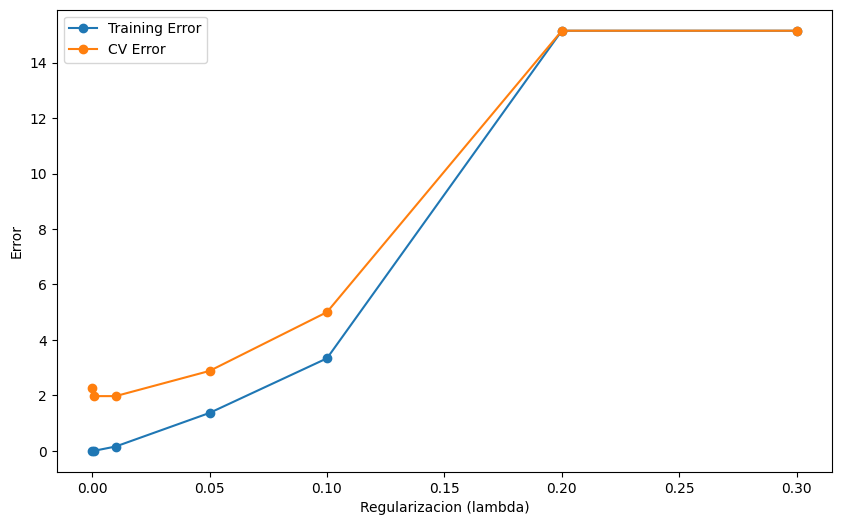

In [ ]:
#DIBUJAMOS GRAFICA PARA ENCONTRAR EL VALOR OPTIMO DE REGULARIZACION
regularization_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
training_errors = [training_performance[reg_value] for reg_value in regularization_values]
cv_errors = [validation_performance[reg_value] for reg_value in regularization_values]

# Dibujar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(regularization_values, training_errors, marker='o', label='Training Error')
plt.plot(regularization_values, cv_errors, marker='o', label='CV Error')
plt.xlabel('Regularizacion (lambda)')
plt.ylabel('Error')
plt.legend()
plt.show()


In [ ]:
#MODELO COMPLEJO CON REGULARIZACION L2 IDEAL
class NeuralNetworkComplexIdeal(nn.Module):
    def __init__(self):
        super(NeuralNetworkComplexIdeal, self).__init__()
        self.fc1 = nn.Linear(1900, 120)
        self.fc2 = nn.Linear(120, 40)
        self.fc3 = nn.Linear(40, 6)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model_complex_ideal = NeuralNetworkComplexIdeal()

criterion = nn.CrossEntropyLoss()
optimizer_complex = optim.Adam(model_complex_ideal.parameters(), lr=0.001, weight_decay=0.01)


for epoch in range(num_epochs):
    model_complex_ideal.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer_complex.zero_grad()
        outputs = model_complex_ideal(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_complex.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Loss: {epoch_loss:.4f}, Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model_complex_ideal.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model_complex_ideal(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')



Loss: 1.1193, Error Train: 29.80%
Loss: 0.3387, Error Train: 8.59%
Loss: 0.1392, Error Train: 3.03%
Loss: 0.0849, Error Train: 1.67%
Loss: 0.0622, Error Train: 1.36%
Loss: 0.0486, Error Train: 0.86%
Loss: 0.0448, Error Train: 0.81%
Loss: 0.0416, Error Train: 0.81%
Loss: 0.0415, Error Train: 0.96%
Loss: 0.0484, Error Train: 0.81%
Loss: 0.0314, Error Train: 0.71%
Loss: 0.0305, Error Train: 0.51%
Loss: 0.0296, Error Train: 0.56%
Loss: 0.0403, Error Train: 0.91%
Loss: 0.0273, Error Train: 0.61%
Loss: 0.0251, Error Train: 0.45%
Loss: 0.0245, Error Train: 0.45%
Loss: 0.0238, Error Train: 0.35%
Loss: 0.0254, Error Train: 0.61%
Loss: 0.0238, Error Train: 0.45%
Loss: 0.0241, Error Train: 0.45%
Loss: 0.0699, Error Train: 1.77%
Loss: 0.0272, Error Train: 0.81%
Loss: 0.0208, Error Train: 0.25%
Loss: 0.0210, Error Train: 0.30%
Loss: 0.0226, Error Train: 0.20%
Loss: 0.0211, Error Train: 0.30%
Loss: 0.0213, Error Train: 0.25%
Loss: 0.0357, Error Train: 0.81%
Loss: 0.0282, Error Train: 0.56%
Loss: 0.0

In [ ]:
#MODELO SIMPLE
#Creamos el modelo de red neuronal
class NeuralNetworkSimple(nn.Module):
    def __init__(self):
        super(NeuralNetworkSimple, self).__init__()
        #capa 1 de 6 individuos
        self.fc1 = nn.Linear(1900, 6)
        #capa 2 de 6  individuos
        self.fc2 = nn.Linear(6, 6)


    def forward(self, x):
      #capa 1 con activacion relu
        x = torch.relu(self.fc1(x))
        #capa 2 con activacion lineal
        x = self.fc2(x)
        return x

#creamos una instancia de la clase que hemos creado
model = NeuralNetworkSimple()

#definidmos la función de perdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


#ENTRENAMIENTO
num_epochs = 1000
for epoch in range(num_epochs):
    #activamos el modo de entrenamiento del modelo
    model.train()
    running_loss = 0.0
    misclassified_train = 0
    total_train = 0

    for inputs, labels in cargador_entrenamiento:
        optimizer.zero_grad()
        #generamos predicciones
        outputs = model(inputs)
        #calculamos la perdida
        loss = criterion(outputs, labels)
        #retropropagamos el error
        loss.backward()
        #actualizamos parametros del optimizador
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        #calculamos porcentaje de error en entrenamiento
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        misclassified_train += (predicted != labels).sum().item()

    epoch_loss = running_loss / len(conjunto_entrenamiento)
    misclassified_percentage_train = (misclassified_train / total_train) * 100
    print(f'Error Train: {misclassified_percentage_train:.2f}%')

#EVALUAR CON CV
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_validacion:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error CV: {misclassified_percentage:.2f}%')



Error Train: 55.61%
Error Train: 6.46%
Error Train: 1.67%
Error Train: 0.76%
Error Train: 0.66%
Error Train: 0.30%
Error Train: 0.20%
Error Train: 0.10%
Error Train: 0.10%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train: 0.00%
Error Train

In [ ]:
model_complex_ideal.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_prueba:
        outputs = model_complex_ideal(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error en el conjunto de test para el MODELO IDEAL: {misclassified_percentage:.2f}%')

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in cargador_prueba:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
misclassified_percentage = (1 - accuracy) * 100
print(f'Error en el conjunto de test para el MODELO SIMPLE: {misclassified_percentage:.2f}%')

Error en el conjunto de test para el MODELO IDEAL: 1.97%
Error en el conjunto de test para el MODELO SIMPLE: 2.87%


### **MODELO DE SVM**

In [ ]:
##BUSCAMOS EL VALOR IDEAL PARA C Y SIGMA
valores = [0.01,0.03,0.1,0.3,1,3,10,30]
best_score = 0
for valC in valores:
    for valSig in valores:
        svmGaussIdeal = SVC(kernel='rbf', C=valC,  gamma=1 / (2 * valSig**2))
        svmGaussIdeal.fit(XTrain, yTrain)
        scoreVal = svmGaussIdeal.score(XVal, yVal)
        scoreTest = svmGaussIdeal.score(XTest, yTest)

        if scoreVal > best_score and scoreTest > best_score:
            best_score = (scoreVal + scoreTest) / 2
            best_valC = valC
            best_valSig = valSig

# Imprimir los valores con el mejor puntaje
print("Mejor puntaje promedio:", best_score)
print("Mejor C encontrado:", best_valC)
print("Mejor sigma encontrado:", best_valSig)


Mejor puntaje promedio: 0.9818342272956494
Mejor C encontrado: 30
Mejor sigma encontrado: 10


In [ ]:
c = 30
sigma = 10
svm = SVC(kernel='rbf', C=c,  gamma=1 / (2 * sigma**2))
svm.fit(XTrain,yTrain)
scoreVal = svm.score(XVal, yVal)
scoreTest = svm.score(XTest, yTest)
print("Score eval: ", scoreVal, "Score Test: ", scoreTest)

Score eval:  0.9848484848484849 Score Test:  0.9788199697428139


Score eval:  0.8833333333333333 Score Test:  0.8789712556732224


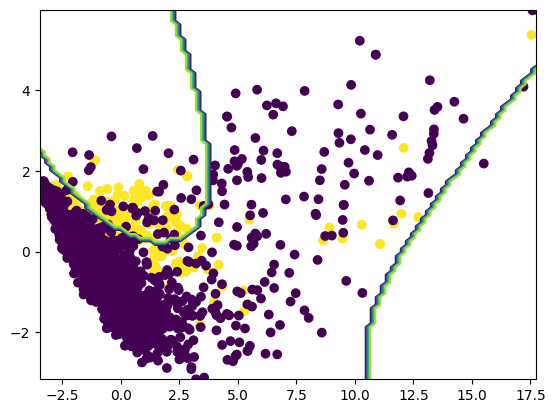

In [ ]:
#Conseguimos la mayor precision para los valores C =30 y sigma = 10, precision de 0.9818
c = 30
sigma = 10

##COMO HAY DEMASIADAS DIMENSIONES, VAMOS A SIMPLIFICARLAS PARA PODER VISUALIZARLO
from sklearn.decomposition import PCA

# Reducir la dimensionalidad de XTrain a 2 dimensiones
pca = PCA(n_components=2)
XTrain_pca = pca.fit_transform(XTrain)
XVal_pca =pca.fit_transform(XVal)
XTest_pca =pca.fit_transform(XTest)

svm = SVC(kernel='rbf', C=c,  gamma=1 / (2 * sigma**2))
svm.fit(XTrain_pca,yTrain)
scoreVal = svm.score(XVal_pca, yVal)
scoreTest = svm.score(XTest_pca, yTest)
print("Score eval: ", scoreVal, "Score Test: ", scoreTest)




# Trazar el límite de decisión
plot_decision_boundary(XTrain_pca, yTrain, svm)

